# **Beginner's Python for Engineers: Final Project**

In this Jupyter Notebook, we aim to analyze the ***correlations between economic and health indicators on a continental level*** from 2000 to 2015. Using the base and additional datasets, we explore factors such as GDP, healthcare expenditure, life expectancy, and adult mortality across different continents. Through visualizations like line graphs depicting mean GDP over time and confidence intervals highlighting key years, such as 2008's global crisis, we seek to uncover insights into the dynamics of global economies and healthcare systems. **Throughout this report, we aim to answer these questions:**
1. To what extent do economic factors correlate with certain health indicators on a continental level?
2. How does a significant economic downturn, such as the global crisis in 2008, affect the health outcomes of continents?


## **Group members and tasks**

 **Group 14**:
> - Dang Ngan: Cleaning and analysing the base dataset
> - Devi Pirya: Cleaning and analysing the additional dataset
> - Joonas Nivala: Data visualization
> - Nguyen Khang: Data visualization



## **1. Loading the data**

### **1.1 Introduction to the datasets**

There are two datasets we will use to proceed our analysis:
>
1. The base dataset: '**Countries_base.csv**'
  - Usage objectives: Gross Domestic Product (GDP) and the percentage of GDP allocated to healthcare across continents (2000 to 2015).
  - Targeted columns: 'Country Name', 'Year', 'GDP', 'Health Expenditure (% GDP)', 'Continent Name'
2. The additional dataset: '**Life Expectancy Data.csv**'
 - Usage objectives: Average life expectancy and adult mortality rates across countries, organized by continent (2000 to 2015).
 - Targeted columns: 'Country', 'Year', 'Life expectancy', 'Adult Mortality'

### **1.2 Importing the data**

Firstly, download two CSV files, **'Life Expectancy Data.csv'** and **'Countries_base.csv'** using `gdown`.

- `gdown`: a Python package enabling file downloads from Google Drive using the file IDs




In [1]:
! gdown --id 1wlDkmQlSnkR47-SaAo9quLZVCg1zrvD_
! gdown --id 1KZN4sS64egClJmcjwCXRglKEHff9Nc3Z

/usr/local/lib/python3.10/dist-packages/gdown/cli.py:138: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1wlDkmQlSnkR47-SaAo9quLZVCg1zrvD_
To: /content/Life Expectancy Data.csv
100% 333k/333k [00:00<00:00, 76.8MB/s]
/usr/local/lib/python3.10/dist-packages/gdown/cli.py:138: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1KZN4sS64egClJmcjwCXRglKEHff9Nc3Z
To: /content/Countries_base.csv
100% 1.70M/1.70M [00:00<00:00, 84.8MB/s]


## **2. Cleaning the data prior to combination**

### **2.1 Getting started**


We begin by importing the Pandas, Numpy and Matplotlib.pyplot libraries using the `import` function. These libraries are primarily utilized in this notebook for data access, cleaning, calculation, and visualization.
- `import`: load external libraries and enable access to their functionalities

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### **2.2 Reading Data and Setting Display Format**


In this code block, we prepare data for analysis by adjusting the format and importing datasets into pandas DataFrames.

- `display.float_format`: controls the formatting of floating-point numbers in the display output.
- `pd.read_csv()`: reads data from the CSV files **'Countries_base.csv'** and **'Life Expectancy Data.csv'** into pandas DataFrames

In [3]:
pd.set_option('display.float_format', '{:,.2f}'.format)
base_data = pd.read_csv('Countries_base.csv')
additional_data = pd.read_csv('Life Expectancy Data.csv')

### **2.3 Preparing the datasets**

Next, we preprocess the base dataset by selecting specific columns of interest and filtering entries based on the years 2000 through 2015.
- `.loc`: a Pandas method used to select the specified columns from the base dataset

In [4]:
selected_columns = ['Country Name', 'Year', 'GDP',
                        'Health Expenditure (% GDP)', 'Continent Name']
base_data = base_data.loc[:, selected_columns]
base_data = base_data[(base_data['Year'] >= 2000) & (base_data['Year'] <= 2015)]

Similarly, we filtered the desired columns in the additional dataset.

In [5]:
selected_columns = ['Country', 'Year', 'Life expectancy ', 'Adult Mortality']
additional_data = additional_data.loc[:, selected_columns]
additional_data = additional_data[(additional_data['Year'] >= 2000) & (additional_data['Year'] <= 2015)]

Next, we renamed the column 'Country' to 'Country Name' to enable merging of the two datasets using `.rename()`.

In [6]:
additional_data.rename(columns={'Country': 'Country Name'}, inplace=True)
additional_data['Country Name'] = additional_data['Country Name'].replace('United States of America', 'United States')

## **3. Combining the data**

In this step, we merge the base dataset with the additional dataset based on 'Country Name' and 'Year'. It is then stored as 'base_data".

- `pd.merge()`: a Pandas function used to combine two DataFrame objects based on one or more common columns

In [7]:
base_data = pd.merge(base_data, additional_data, on=['Country Name', 'Year'], how='left')

Then, we remove any rows with missing values by using the `.dropna()` method.

In [8]:
base_data.dropna(inplace=True)

Finally, a copy of the processed additional dataset is created for subsequent operations.

In [9]:
additional_data = base_data.copy()

## **4. Calculating statistical properties**

### **4.1 Calculations from the base dataset**

Firstly, we rename the columns for simplicity.

In [10]:
base_data.rename(columns={'Country Name': 'country',
                              'Year': 'year',
                              'Health Expenditure (% GDP)': 'health_expenditure (% GDP)',
                              'Continent Name': 'continent_name'}, inplace=True)

We count the number of countries in each continent-year group, renaming the series as 'sample_size'.

- `.groupby()`: a method used to group data based on one or more columns for future data aggregations or transformations

In [11]:
sample_size = base_data.groupby(['continent_name', 'year'])['country'].count().rename('number of countries')

We calculate the means and standard deviations of GDP and health expenditure (% GDP) for each continent-year group, stored in 'mean_GDP' and 'mean_health_expenditure' respectively.

- `.agg()`: a method used to apply one or more aggregation functions to grouped data, computing multiple summary statistics for each group
  - mean: a measure of central tendency that represents the typical value of a dataset
  - standard deviation: a measure of the dispersion or spread of a dataset around the mean

In [12]:
mean_GDP = base_data.groupby(['continent_name', 'year'])['GDP'].agg(['mean', 'std'])
mean_health_expenditure = base_data.groupby(['continent_name', 'year'])['health_expenditure (% GDP)'].agg(['mean', 'std'])

We use `rename()` to update column names in the DataFrames, namely 'mean_GDP', 'std_GDP', 'mean_health_expenditure (%GDP)', and 'std_health_expenditure (%GDP)'.

In [13]:
mean_GDP.rename(columns={'mean': 'mean_GDP', 'std': 'std_GDP'}, inplace=True)
mean_health_expenditure.rename(columns={'mean': 'mean_health_expenditure (%GDP)', 'std': 'std_health_expenditure (%GDP)'}, inplace=True)

We merge the 'mean_GDP' and 'mean_health_expenditure' DataFrames based on 'continent_name' and 'year', resulting in 'GDP_and_health_expenditure'.








In [14]:
GDP_and_health_expenditure = pd.merge(mean_GDP, mean_health_expenditure, on=['continent_name', 'year'], how='left')

Then, we merge 'sample_size' with 'GDP_and_health_expenditure', forming 'base_data'.

In [15]:
base_data = pd.merge(sample_size, GDP_and_health_expenditure, on=['continent_name', 'year'], how='left')

Next, we sort 'base_data' by 'year' and 'continent_name'.

- `sort_values()`: a method used to sort the rows by the values of one or more columns (this case in an ascending order)

In [16]:
base_data.sort_values(by=['year', 'continent_name'], ascending=True, inplace=True)

Finally, we reset the index to ensure a sequential order.

- `reset_index()`: a method used to reset the index to the default integer index, optionally dropping the current index.

In [17]:
base_data.reset_index(inplace=True)

For clarity, we present the DataFrame for the year 2008 as a reference.

In [18]:
base_data_2000 = base_data[base_data['year'] == 2000]
display(base_data_2000)

,continent_name,year,number of countries,mean_GDP,std_GDP,mean_health_expenditure (%GDP),std_health_expenditure (%GDP)
0,Africa,2000,46,"11,654,728,441.59","25,617,798,227.26",4.71,2.16
1,Asia,2000,40,"209,695,593,238.94","798,004,905,861.51",4.56,2.30
2,Europe,2000,40,"201,433,761,973.48","403,425,964,188.68",6.74,1.65
3,North America,2000,18,"658,815,717,434.58","2,404,991,965,567.05",6.02,2.05
4,Oceania,2000,9,"52,765,589,085.84","137,228,791,782.48",4.95,2.38
5,South America,2000,10,"122,118,872,771.93","205,741,515,364.27",6.13,2.09


***
> ***After calculating some important factors regarding the dataset, we will utilize this data to gain a clearer understanding of two significant economic factors: GDP and national health expenditure as a percentage of GDP, and how this data is distributed continentally.***
***



### **4.2 Calculations from the additional dataset**

Firstly, we select desired columns from additional_data based on the list 'selected_columns' using `.loc[]`.

In [19]:
selected_columns = ['Country Name', 'Year', 'Life expectancy ', 'Adult Mortality', 'Continent Name']
additional_data = additional_data.loc[:, selected_columns]

Then, we rename the columns for simplicity.

In [20]:
additional_data.rename(columns={'Country Name': 'country', 'Year': 'year','Continent Name': 'continent_name', 'Life expectancy ': 'life_expectancy','Adult Mortality': 'adult_mortality'}, inplace=True)

We apply the `list` function to the 'life_expectancy' and 'adult_mortality' columns within each group.

In [21]:
life_data = additional_data.groupby(['continent_name', 'year'])['life_expectancy'].apply(list)
adult_data = additional_data.groupby(['continent_name', 'year'])['adult_mortality'].apply(list)

We similarly create two new DataFrames, 'mean_life_expectancy' and 'mean_adult_mortality', by calculating the means and standard deviations using the `.agg()` method.

In [22]:
mean_life_expectancy = additional_data.groupby(['continent_name', 'year'])['life_expectancy'].agg(['mean', 'std'])
mean_adult_mortality = additional_data.groupby(['continent_name', 'year'])['adult_mortality'].agg(['mean', 'std'])

We use `.rename()` to update column names in the DataFrames.

In [23]:
mean_life_expectancy.rename(columns={'mean': 'mean_life_expectancy', 'std': 'std_life_expectancy'}, inplace=True)
mean_adult_mortality.rename(columns={'mean': 'mean_adult_mortality', 'std': 'std_adult_mortality'}, inplace=True)

This line of code merges two DataFrames, 'mean_life_expectancy' and 'mean_adult_mortality', based on the common columns 'continent_name' and 'year' using a left join.







In [24]:
additional_data = pd.merge(mean_life_expectancy, mean_adult_mortality, on=['continent_name', 'year'], how='left')

For clarity, we present the DataFrame for the year 2000 as a reference.

In [25]:
additional_data_2000 = additional_data.reset_index(inplace=True)
additional_data_2000 = additional_data[additional_data['year'] == 2000]
display(additional_data_2000)

,continent_name,year,mean_life_expectancy,std_life_expectancy,mean_adult_mortality,std_adult_mortality
0,Africa,2000,54.90,9.01,264.59,202.15
16,Asia,2000,68.89,6.21,149.45,90.09
32,Europe,2000,74.82,4.28,103.25,76.37
48,North America,2000,72.39,4.77,150.22,50.52
64,Oceania,2000,69.69,6.63,152.44,109.37
80,South America,2000,72.89,4.19,159.00,62.56


***
> ***The additional dataset provides insights into healthcare factors such as average life expectancy and adult mortality, and how they are distributed across continents. By combining this valuable information with the economic factors found in the base dataset, we aim to identify correlations between these variables.***
***

### **4.3 Final merging of the base and additional datasets**

Finally, we use `merge()` to combine 'base_data' and 'additional_data_with_continent', on 'continent_name' and 'year' columns using a left join method.

In [26]:
file = pd.merge(base_data, additional_data, on=['continent_name', 'year'], how='left')

For clarity, we present the DataFrame for the year 2008 as a reference.

In [27]:
file_2000 = file.reset_index(inplace=True)
file_2000 = file[file['year'] == 2000]
display(file_2000)

,index,continent_name,year,number of countries,mean_GDP,std_GDP,mean_health_expenditure (%GDP),std_health_expenditure (%GDP),mean_life_expectancy,std_life_expectancy,mean_adult_mortality,std_adult_mortality
0,0,Africa,2000,46,"11,654,728,441.59","25,617,798,227.26",4.71,2.16,54.90,9.01,264.59,202.15
1,1,Asia,2000,40,"209,695,593,238.94","798,004,905,861.51",4.56,2.30,68.89,6.21,149.45,90.09
2,2,Europe,2000,40,"201,433,761,973.48","403,425,964,188.68",6.74,1.65,74.82,4.28,103.25,76.37
3,3,North America,2000,18,"658,815,717,434.58","2,404,991,965,567.05",6.02,2.05,72.39,4.77,150.22,50.52
4,4,Oceania,2000,9,"52,765,589,085.84","137,228,791,782.48",4.95,2.38,69.69,6.63,152.44,109.37
5,5,South America,2000,10,"122,118,872,771.93","205,741,515,364.27",6.13,2.09,72.89,4.19,159.00,62.56


## **5. Visualizing and Analyzing data**

### **5.1 Line graphs**
> *We aim to illustrate the changes in GDP, health expenditure, life expectancy, and adult mortality for each continent from 2000 to 2015. As the data follows a time series, we opt for line graphs to represent these indicators. By analyzing these factors continentally and longitudinally, our goal is to identify patterns, disparities, and potential correlations.*

Firstly, we extract data for each continent by filtering based on the values in the 'continent_name' column.

In [28]:
Asia = file[file['continent_name'] == 'Asia']
Europe = file[file['continent_name'] == 'Europe']
Africa = file[file['continent_name'] == 'Africa']
Oceania = file[file['continent_name'] == 'Oceania']
N_America = file[file['continent_name'] == 'North America']
S_America = file[file['continent_name'] == 'South America']

We use the Matplotlib library to plot a line graph depicting the mean GDP of each continent from 2000 to 2015.

- `.subplots()`: a function used to create a figure and a set of subplots within that figure
- `.set_xlabel()` and `.set_ylabel()`: methods used to set the label for the x-axis and y-axis
- `.set_title()`: a function used to set the title of a plot
- `.plot()`: a method used to create various types of plots based on the data provided and additional parameters specified
- `.legend()`: a method used to add a legend to a plot, providing information about the different elements present in the plot
- `.text()`: a function allows you annotate plots with text in a specified position



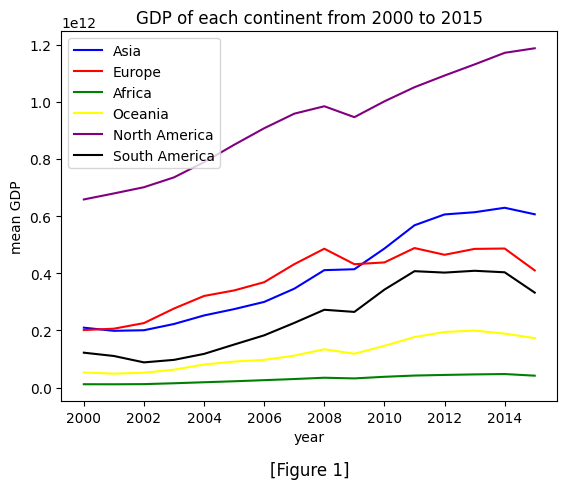

In [29]:
fig1, ax1 = plt.subplots()
ax1.set_xlabel('year')
ax1.set_ylabel('mean GDP')
ax1.set_title("GDP of each continent from 2000 to 2015")
ax1.plot(Asia['year'], Asia['mean_GDP'].values, label="Asia", color="blue")
ax1.plot(Europe['year'], Europe['mean_GDP'].values, label="Europe", color="red")
ax1.plot(Africa['year'], Africa['mean_GDP'].values, label="Africa", color="green")
ax1.plot(Oceania['year'], Oceania['mean_GDP'].values, label="Oceania", color="yellow")
ax1.plot(N_America['year'], N_America['mean_GDP'].values, label="North America", color="purple")
ax1.plot(S_America['year'], S_America['mean_GDP'].values, label="South America", color="black")
ax1.text(0.5, -0.2, "[Figure 1]", transform=ax1.transAxes, fontsize=12, horizontalalignment='center')
ax1.legend(loc="upper left")

***
> From 2000 to 2015, the average GDP of each continent reveals interesting trends and disparities.
> - **North America:** had the highest mean GDP, outpacing every other continent
> - **Africa:** consistently maintained the lowest average GDP
> - **Asia and Europe**:
   - Both demonstrated similar trends until 2010
   - In 2015, Asia had the second-highest average GDP, surpassing Europe by almost 1.5 times
> - **South America and Oceania:**
   - Initially exhibited comparable average GDP levels
   - South America experienced a significant surge around 2010, becoming the fourth-wealthiest continent by the end of 2015
>
> One key takeaway: Europe might have encountered the most pronounced impact from the global financial crisis, experiencing a significant decline in GDP post-2008 compared to other continents.
***

Next, we plot a line graph of the health expenditure of each continents from 2000 to 2015. Additionally, we color the continents the same as the first graph to make it consistent.

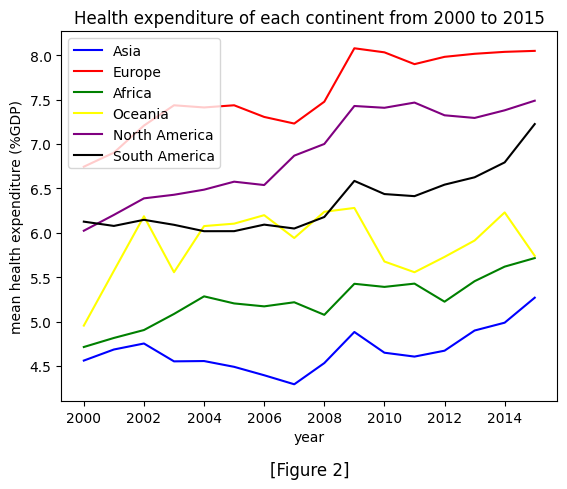

In [30]:
fig2, ax2 = plt.subplots()
ax2.set_xlabel('year')
ax2.set_ylabel('mean health expenditure (%GDP)')
ax2.set_title("Health expenditure of each continent from 2000 to 2015")
ax2.plot(Asia['year'], Asia['mean_health_expenditure (%GDP)'].values, label="Asia", color="blue")
ax2.plot(Europe['year'], Europe['mean_health_expenditure (%GDP)'].values, label="Europe", color="red")
ax2.plot(Africa['year'], Africa['mean_health_expenditure (%GDP)'].values, label="Africa", color="green")
ax2.plot(Oceania['year'], Oceania['mean_health_expenditure (%GDP)'].values, label="Oceania", color="yellow")
ax2.plot(N_America['year'], N_America['mean_health_expenditure (%GDP)'].values, label="North America", color="purple")
ax2.plot(S_America['year'], S_America['mean_health_expenditure (%GDP)'].values, label="South America", color="black")
ax2.text(0.5, -0.2, "[Figure 2]", transform=ax2.transAxes, fontsize=12, horizontalalignment='center')
ax2.legend(loc="upper left")

***
> The analysis of the average percentage of GDP spent on healthcare across continents reveals several key observations. Overall, there was a slight upward trend in the percentage of GDP spent on healthcare across continents from 2000 to 2015.
> - **Africa**: ranked second lowest with around 4.7%
> - **South America, North America, and Oceania**: exhibited comparable levels of healthcare expenditure, athough Oceania experienced intense fluctuations
> - **Asia**: had the lowest percentage of GDP spent on healthcare, while **Europe** consistently allocated the highest, nearly double that of Asia's
***

We then plot a line graph of the life expectancy of each continents from 2000 to 2015.

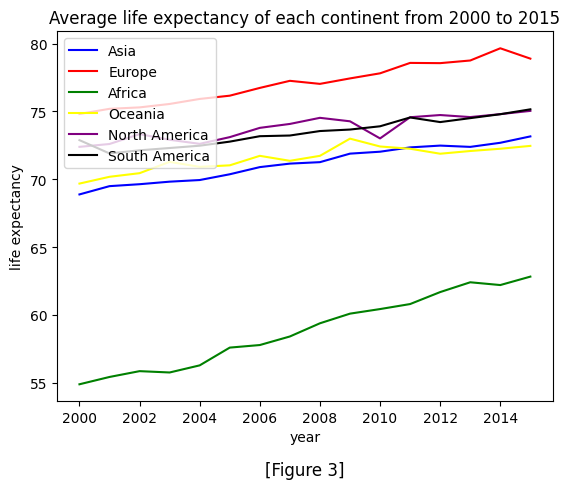

In [31]:
fig3, ax3 = plt.subplots()
ax3.set_xlabel('year')
ax3.set_ylabel('life expectancy')
ax3.set_title("Average life expectancy of each continent from 2000 to 2015")
ax3.plot(Asia['year'], Asia['mean_life_expectancy'].values, label="Asia", color="blue")
ax3.plot(Europe['year'], Europe['mean_life_expectancy'].values, label="Europe", color="red")
ax3.plot(Africa['year'], Africa['mean_life_expectancy'].values, label="Africa", color="green")
ax3.plot(Oceania['year'], Oceania['mean_life_expectancy'].values, label="Oceania", color="yellow")
ax3.plot(N_America['year'], N_America['mean_life_expectancy'].values, label="North America", color="purple")
ax3.plot(S_America['year'], S_America['mean_life_expectancy'].values, label="South America", color="black")
ax3.text(0.5, -0.2, "[Figure 3]", transform=ax3.transAxes, fontsize=12, horizontalalignment='center')
ax3.legend(loc="upper left")

***
> Overall, there was an upward trend in average life expectancy across continents from 2000 to 2015.
> - **Africa**: had the lowest life expectancy, reaching around 60 years by 2015.
> - **South America, North America, Oceania, and Asia**: had comparable life expectancies, initially around 70 years and reaching approximately 75 years
> - **Europe**: boasted the highest average life expectancy, nearing 80 years by the end of 2015
>
> Notably, while each continent experienced an average growth of around 5 years over the 15-year period, Africa stood out with a significantly lower life expectancy.
***

In the following codes, we plot a line graph of the adult mortality of each continents from 2000 to 2015.

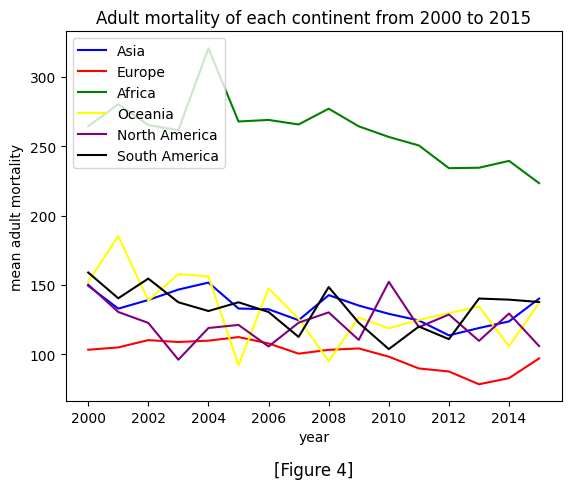

In [32]:
fig4, ax4 = plt.subplots()
ax4.set_xlabel('year')
ax4.set_ylabel('mean adult mortality')
ax4.set_title("Adult mortality of each continent from 2000 to 2015")
ax4.plot(Asia['year'], Asia['mean_adult_mortality'].values, label="Asia", color="blue")
ax4.plot(Europe['year'], Europe['mean_adult_mortality'].values, label="Europe", color="red")
ax4.plot(Africa['year'], Africa['mean_adult_mortality'].values, label="Africa", color="green")
ax4.plot(Oceania['year'], Oceania['mean_adult_mortality'].values, label="Oceania", color="yellow")
ax4.plot(N_America['year'], N_America['mean_adult_mortality'].values, label="North America", color="purple")
ax4.plot(S_America['year'], S_America['mean_adult_mortality'].values, label="South America", color="black")
ax4.text(0.5, -0.2, "[Figure 4]", transform=ax4.transAxes, fontsize=12, horizontalalignment='center')
ax4.legend(loc="upper left")

***
> Regarding adult mortality, the rate appeared to fluctuate throughout the period:
> - **Africa**: maintained the highest rate, nearly double that of other continents
> - **South America, North America, Oceania, and Asia**: exhibited fluctuating rates around 150, with comparable levels
> - **Europe**: had the lowest adult mortality rate, hovering around 100
***

### **5.2 Confidence Intervals**

> *In this section, we want to portray the confidence interval of the GDP and life expectancy of each continent for the data in 2008 compared to 2015 to assess the impact of the global crisis that occurred during that year. By examining the confidence intervals, we aim to understand the extent to which the economic downturn and associated socio-economic factors influenced GDP and life expectancy trends on a continental level.*
>
>> *About confidence intervals: In general, smaller confidence intervals indicate greater precision and confidence in the estimated mean GDP values, while larger confidence intervals imply greater uncertainty and variability in the data.*

The initial step involves creating subsetted data focusing solely on entries from 2008 and 2015 for further analysis.

In [33]:
file_2008 = file[file['year'] == 2008]
file_2015 = file[file['year'] == 2015]
Life_2008 = life_data.xs(2008, axis=0, level=1, drop_level=False)
Life_2015 = life_data.xs(2015, axis=0, level=1, drop_level=False)
Adult_2008 = adult_data.xs(2008, axis=0, level=1, drop_level=False)
Adult_2015 = adult_data.xs(2015, axis=0, level=1, drop_level=False)

We extract the 'continent_name' column to use for the bar graph later, utilizing the data previously extracted above to calculate the confidence interval. Calculation of the confidence interval:

<p style="text-align:center;"><strong>CF = mean ± z * std / (√n)</strong></p>

Where:
>
- mean: the mean of the data
- z: the standard score (for a 95% confidence interval, z = 1.96)
- std: the standard deviation of the data
- n: the number of countries in the data

In [34]:
continents_2008 = file_2008['continent_name']
upper_mean_GDP_2008 = file_2008['mean_GDP'] + 1.96 * file_2008['std_GDP'] / np.sqrt(file_2008['number of countries'])
lower_mean_GDP_2008 = file_2008['mean_GDP'] - 1.96 * file_2008['std_GDP'] / np.sqrt(file_2008['number of countries'])

continents_2015 = file_2015['continent_name']
upper_mean_GDP_2015 = file_2015['mean_GDP'] + 1.96 * file_2015['std_GDP'] / np.sqrt(file_2015['number of countries'])
lower_mean_GDP_2015 = file_2015['mean_GDP'] - 1.96 * file_2015['std_GDP'] / np.sqrt(file_2015['number of countries'])

We utilize the bar plots to represent the confidence intervals, where the lower bound is depicted by the blue bar and the upper bound by the orange bar. However, due to small sampling sizes (under 20), the lower bounds of Oceania, North America, and South America are negative.
- `.arrange()`: a method used to create an array of evenly spaced values within a specified range
- `len()`: a function used to determine the length or number of elements in an object
- `.bar()`: a function used to create a bar plot
- `.xticks()`: a function used to customize the tick labels on the x-axis of a plot and allow you to specify the positions and labels of the ticks
- `.tight_layout()`:  a function automatically adjusts the subplot parameters to fit the figure area, preventing overlapping of subplot elements



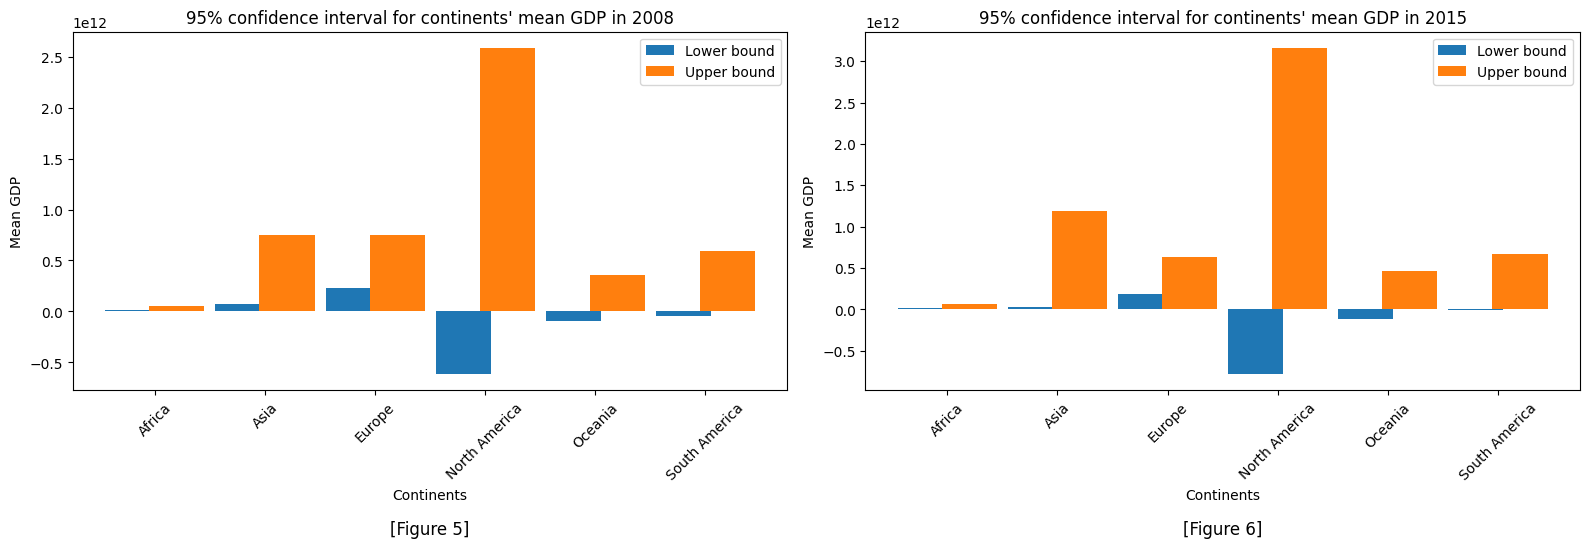

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax5 = axes[0]
X_axis = np.arange(len(continents_2008))
ax5.bar(X_axis - 0.2, lower_mean_GDP_2008, 0.5, label='Lower bound')
ax5.bar(X_axis + 0.2, upper_mean_GDP_2008, 0.5, label='Upper bound')
ax5.set_xticks(X_axis)
ax5.set_xticklabels(continents_2008, rotation=45)
ax5.set_xlabel("Continents")
ax5.set_ylabel("Mean GDP")
ax5.set_title("95% confidence interval for continents' mean GDP in 2008")
ax5.text(0.5, -0.4, "[Figure 5]", transform=ax5.transAxes, fontsize=12, horizontalalignment='center')
ax5.legend()

ax6 = axes[1]
X_axis = np.arange(len(continents_2015))
ax6.bar(X_axis - 0.2, lower_mean_GDP_2015, 0.5, label='Lower bound')
ax6.bar(X_axis + 0.2, upper_mean_GDP_2015, 0.5, label='Upper bound')
ax6.set_xticks(X_axis)
ax6.set_xticklabels(continents_2015, rotation=45)
ax6.set_xlabel("Continents")
ax6.set_ylabel("Mean GDP")
ax6.set_title("95% confidence interval for continents' mean GDP in 2015")
ax6.text(0.5, -0.4, "[Figure 6]", transform=ax6.transAxes, fontsize=12, horizontalalignment='center')
ax6.legend()

plt.tight_layout()

***
> The analysis of confidence intervals for the mean GDP of each continent in 2008 and 2015 reveals several noteworthy trends and observations.
> - Overall, there was a trend of decreasing confidence intervals over time compared to GDP growth, indicating reduced disruption and uncertainty, except for Asia and North America.
> - Additionally, there was a general upward movement in mean GDP across continents, except for **Europe**.
> - In 2008, **Asia, Europe, and North America** had the largest confidence intervals.
> - By 2015, **Asia**'s confidence interval was approximately 2 times larger than that of itself in 2008.
> - **South America, Africa and Oceania** maintained relatively stable confidence intervals between 2008 and 2015.
***

Next, we compute the confidence interval for the life expectancies of each continent in 2008 and 2015 using the same method for determining the confidence intervals for GDP.

We then plot the box plots for the confidence intervals in 2008 and 2015.

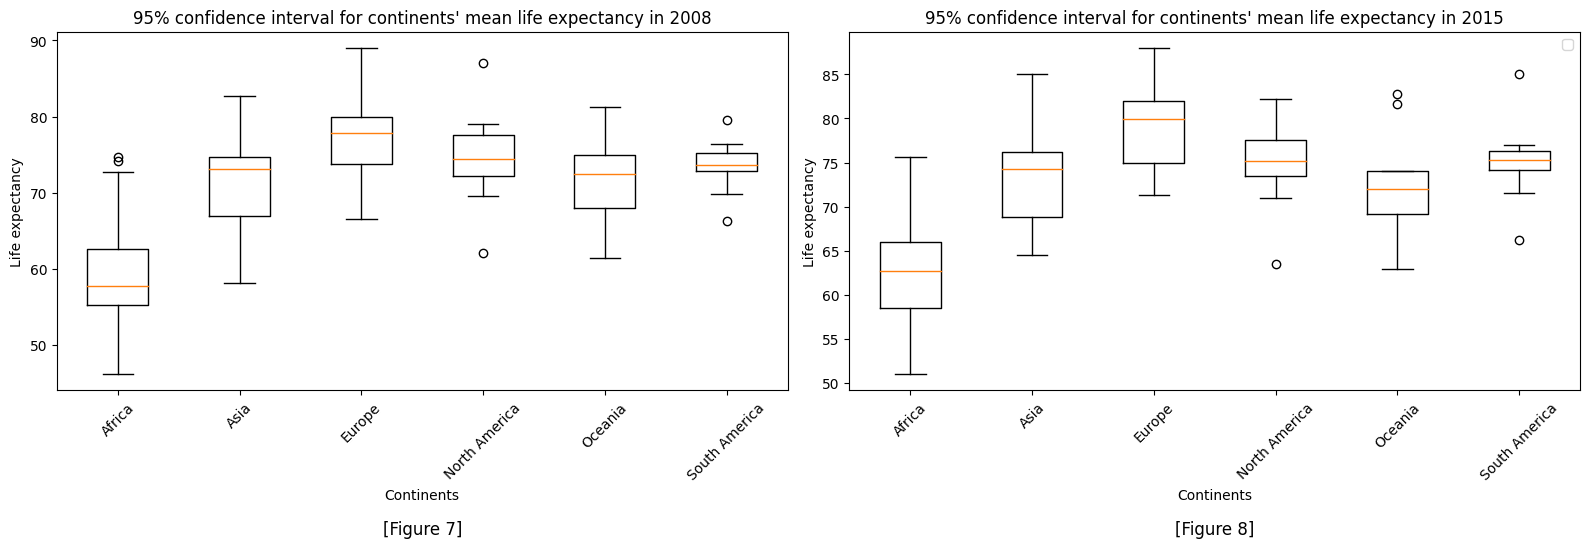

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax7 = axes[0]
ax7.boxplot(Life_2008)
ax7.set_xticklabels(continents_2008, rotation=45)
ax7.set_xlabel("Continents")
ax7.set_ylabel("Life expectancy")
ax7.set_title("95% confidence interval for continents' mean life expectancy in 2008")
ax7.text(0.5, -0.4, "[Figure 7]", transform=ax7.transAxes, fontsize=12, horizontalalignment='center')

ax8 = axes[1]
ax8.boxplot(Life_2015)
ax8.set_xticklabels(continents_2015, rotation=45)
ax8.set_xlabel("Continents")
ax8.set_ylabel("Life expectancy")
ax8.set_title("95% confidence interval for continents' mean life expectancy in 2015")
ax8.text(0.5, -0.4, "[Figure 8]", transform=ax8.transAxes, fontsize=12, horizontalalignment='center')
ax8.legend()

plt.tight_layout()

***
> The analysis of life expectancies in 2008 and 2015 reveals no discernible trend across continents. However, it is evident that life expectancies stabilized despite the global crisis.
***

Lastly, we compute the confidence interval for the adult mortality of each continent in 2008 and 2015 using the same method for determining the confidence intervals for GDP.

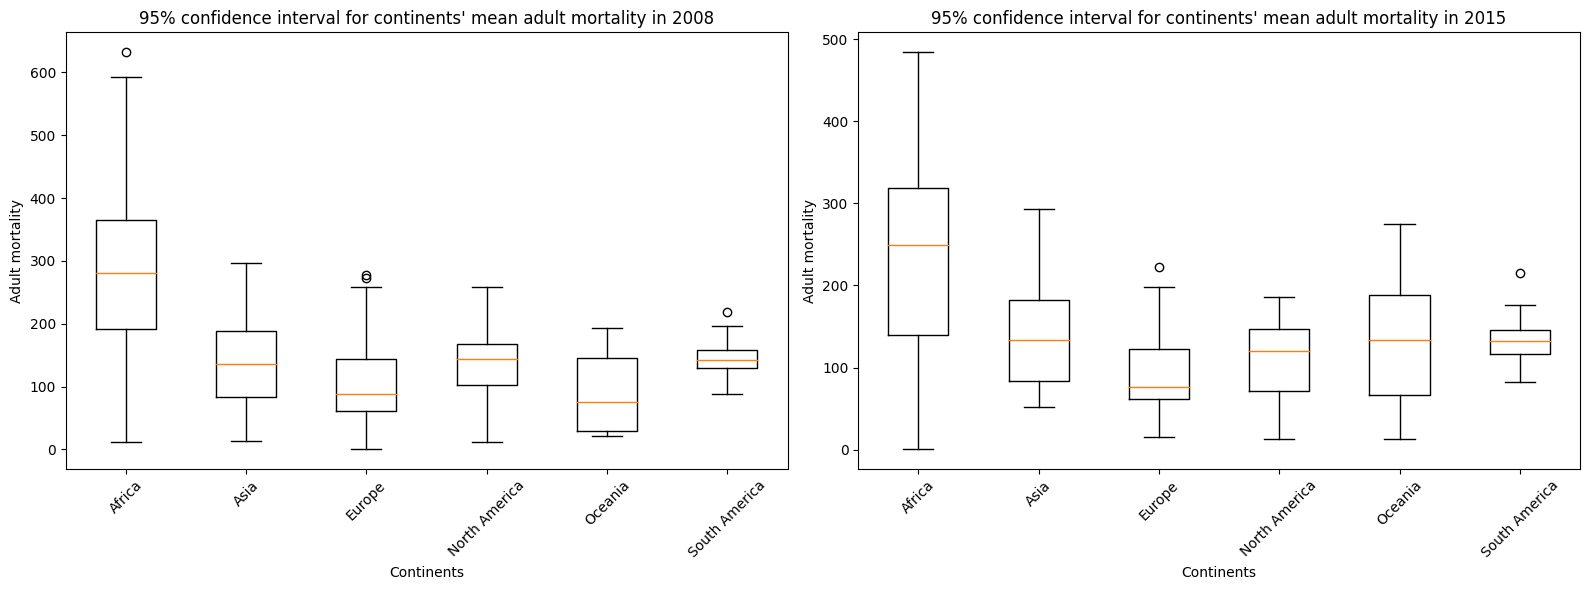

In [37]:
  fig, axes = plt.subplots(1, 2, figsize=(16, 6))

  ax9 = axes[0]
  ax9.boxplot(Adult_2008)
  ax9.set_xticklabels(continents_2008, rotation=45)
  ax9.set_xlabel("Continents")
  ax9.set_ylabel("Adult mortality")
  ax5.text(0.5, -0.4, "[Figure 9]", transform=ax9.transAxes, fontsize=12, horizontalalignment='center')
  ax9.set_title("95% confidence interval for continents' mean adult mortality in 2008")

  ax10 = axes[1]
  ax10.boxplot(Adult_2015)
  ax10.set_xticklabels(continents_2015, rotation=45)
  ax10.set_xlabel("Continents")
  ax10.set_ylabel("Adult mortality")
  ax5.text(0.5, -0.4, "[Figure 10]", transform=ax10.transAxes, fontsize=12, horizontalalignment='center')
  ax10.set_title("95% confidence interval for continents' mean adult mortality in 2015")

  plt.tight_layout()

***
> The analysis of adult mortalities in 2008 and 2015 does not indicate any clear trend across continents. Nonetheless, similar to life expectancy, there is a consistent stability observed despite the global crisis.
***

## **6. Observations and possible reasons**

### **6.1 GDP and health indicators from 2000 to 2015**

In this section, we generate subplots comparing GDP with life expectancy and GDP with adult mortality for each continent using linear regression. In addition, we also include corresponding coefficient points for further analysis.
- `globals()`: a function that retrieves the DataFrame associated with that a given variable
- `np.polyfit()`: a function used to fit a polynomial regression line to the data points to determine the slope and intercept
- `.scatter()`: plots a scatter plot of given data
- `np.corrcoef()`: computes the correlation coefficient between the given variables

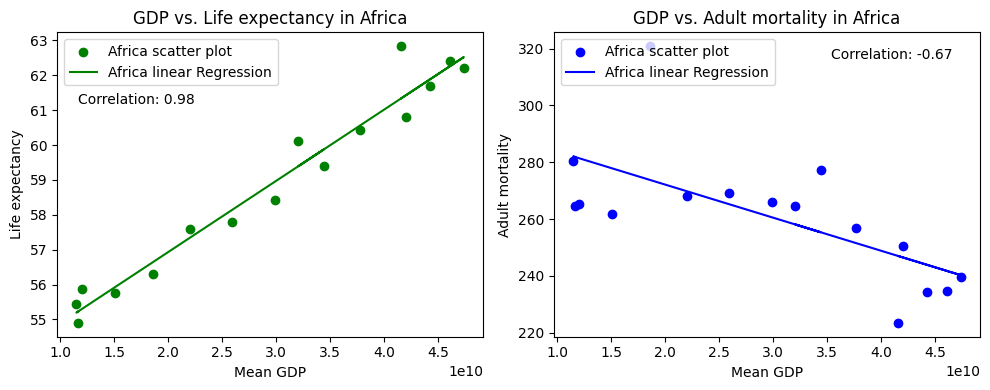

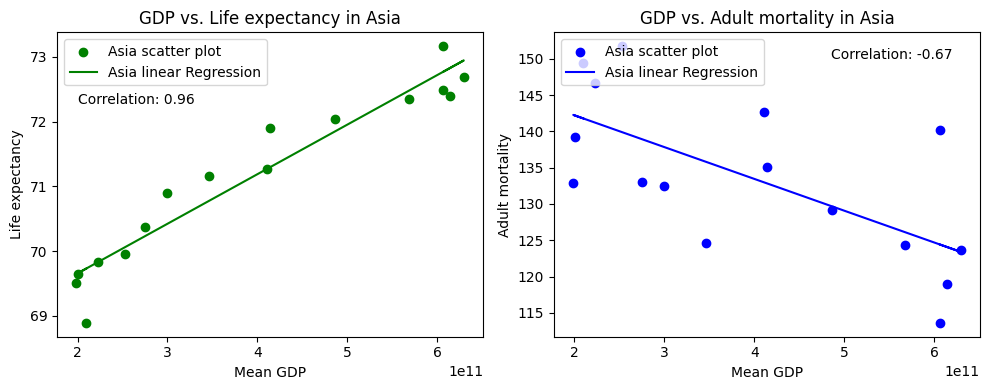

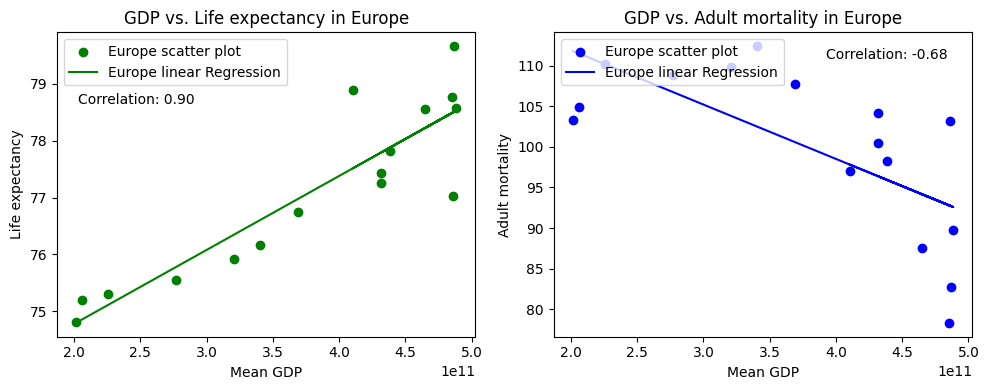

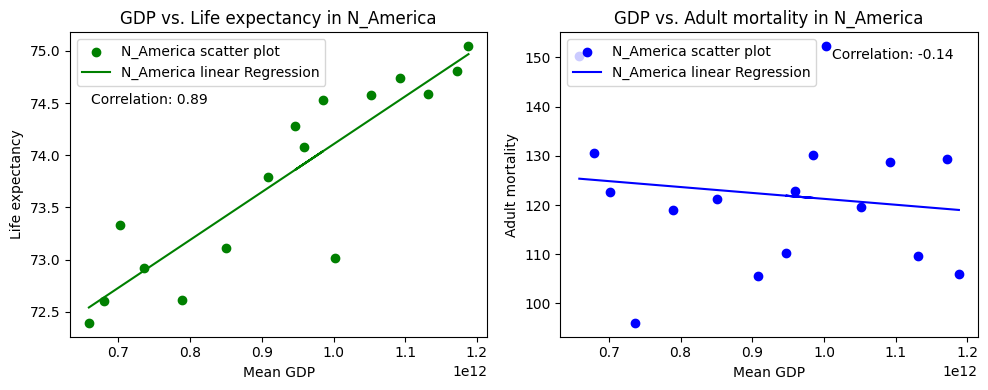

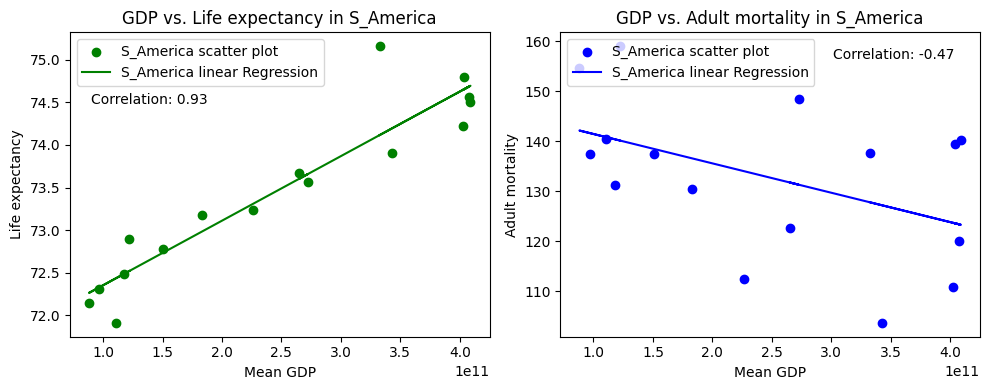

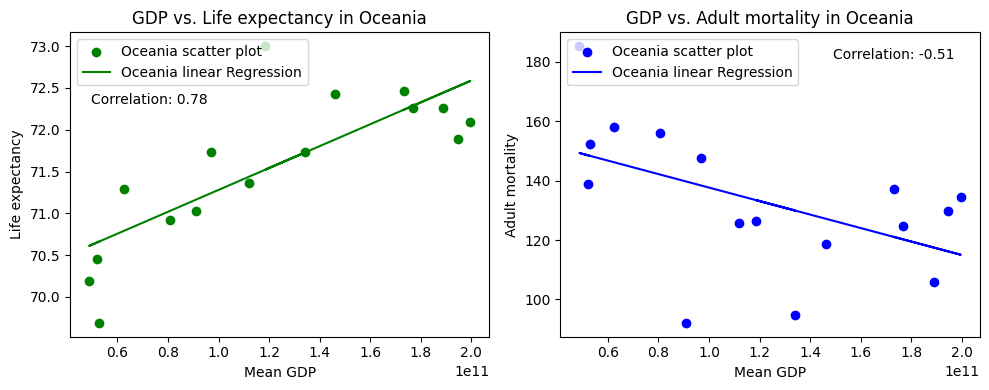

In [38]:
continents = ['Africa', 'Asia', 'Europe', 'N_America', 'S_America', 'Oceania']

for continent_name in continents:
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    continent = globals()[continent_name]

    slope_life_gdp, intercept_life_gdp = np.polyfit(continent['mean_GDP'].values,
                                                    continent['mean_life_expectancy'].values, 1)
    axs[0].scatter(continent['mean_GDP'].values, continent['mean_life_expectancy'].values,
                      label=f"{continent_name} scatter plot", color="green")
    axs[0].plot(continent['mean_GDP'].values,
                   slope_life_gdp * continent['mean_GDP'].values + intercept_life_gdp,
                   color='green', label=f'{continent_name} linear Regression')
    axs[0].set_xlabel('Mean GDP')
    axs[0].set_ylabel('Life expectancy')
    axs[0].set_title(f"GDP vs. Life expectancy in {continent_name}")
    axs[0].legend(loc="upper left")

    slope_mortality_gdp, intercept_mortality_gdp = np.polyfit(continent['mean_GDP'].values,
                                                              continent['mean_adult_mortality'].values, 1)
    axs[1].scatter(continent['mean_GDP'].values, continent['mean_adult_mortality'].values,
                      label=f"{continent_name} scatter plot", color="blue")
    axs[1].plot(continent['mean_GDP'].values,
                   slope_mortality_gdp * continent['mean_GDP'].values + intercept_mortality_gdp,
                   color='blue', label=f'{continent_name} linear Regression')
    axs[1].set_xlabel('Mean GDP')
    axs[1].set_ylabel('Adult mortality')
    axs[1].set_title(f"GDP vs. Adult mortality in {continent_name}")
    axs[1].legend(loc="upper left")

    correlation_life_he = np.corrcoef(continent['mean_GDP'].values,
                                       continent['mean_life_expectancy'].values)[0, 1]
    correlation_mortality_he = np.corrcoef(continent['mean_GDP'].values,
                                            continent['mean_adult_mortality'].values)[0, 1]

    axs[0].text(0.05, 0.8, f'Correlation: {correlation_life_he:.2f}', transform=axs[0].transAxes, fontsize=10,
                ha='left', va='top')
    axs[1].text(0.65, 0.95, f'Correlation: {correlation_mortality_he:.2f}', transform=axs[1].transAxes, fontsize=10,
                ha='left', va='top')

    plt.tight_layout()
    plt.show()


#### **6.1.1 GDP and Life Expectancy**

**Generally, continents with higher average GDP tend to have higher life expectancies.**
- Possible reasons: better healthcare infrastructure, access to medical services, and overall standards of living in wealthier regions.


> *However, there were prolonged low life expectancies in Africa despite some growth in GDP. The sustained levels of average GDP and life expectancy could stem from the **rigidity within global dynamics**. Factors like economic disparities may amplify inequalities in healthcare access and quality, thereby influencing life expectancy.*

#### **6.1.2 GDP and Adult Mortality**


There seemed to be a very slight negative correlation between GDP and adult mortality from 2000 to 2015 (except for North America). However, the data was highly dispersed around the coefficient line in general.
- Indirect investments in healthcare
- Socioeconomic determinants such as education levels, poverty rates, and access to clean water and sanitation could have had a more significant impact
- Differences in environmental conditions may have played a role in adult mortality rates

### **6.2 Percentage of GDP spent on healthcare and health indicators from 2000 to 2015**

Similarly to average GDP, we compute linear regressions regarding health expenditure and health measurements.

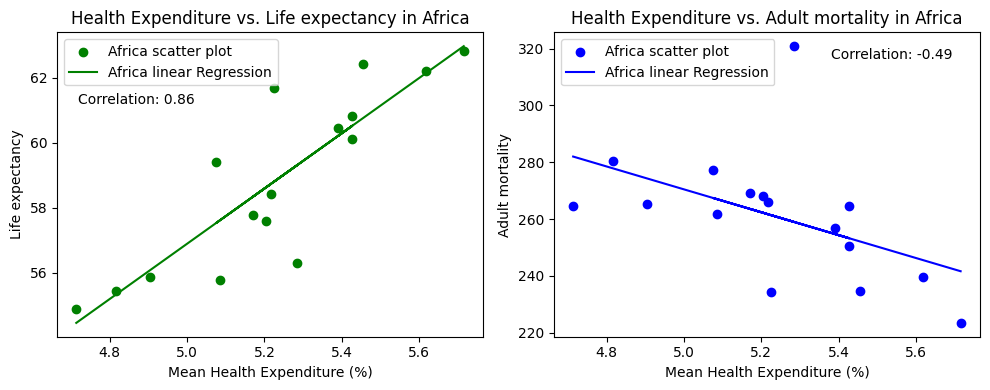

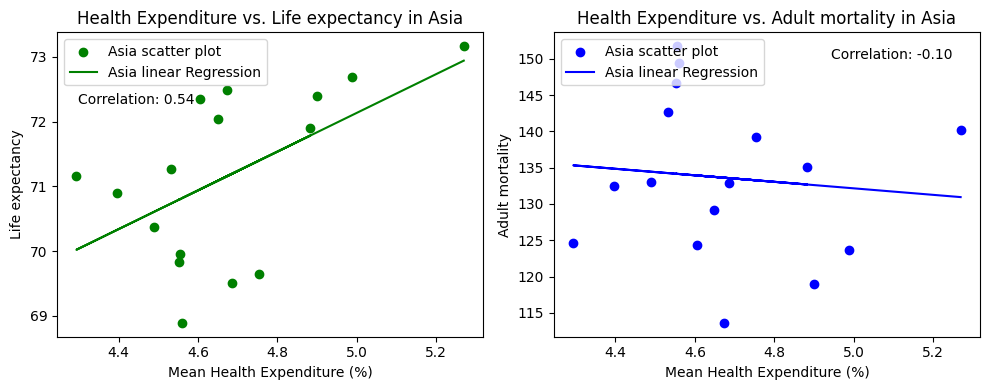

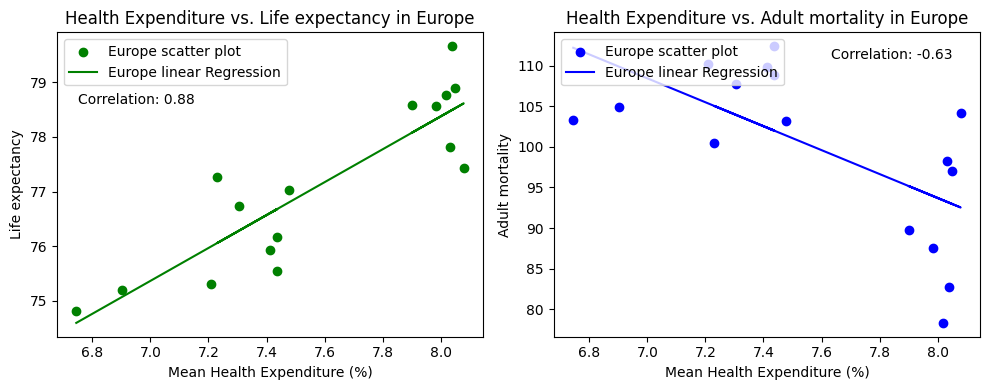

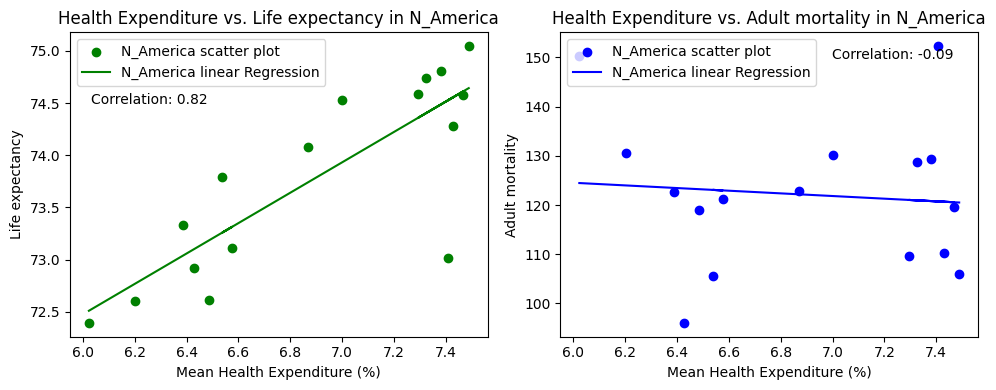

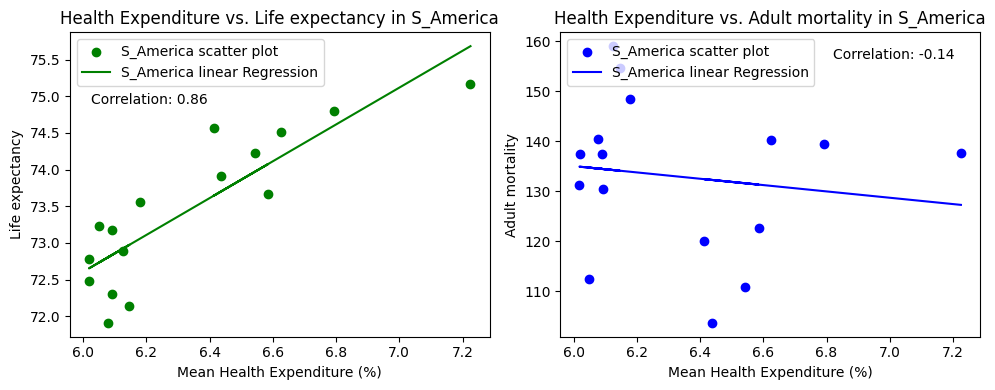

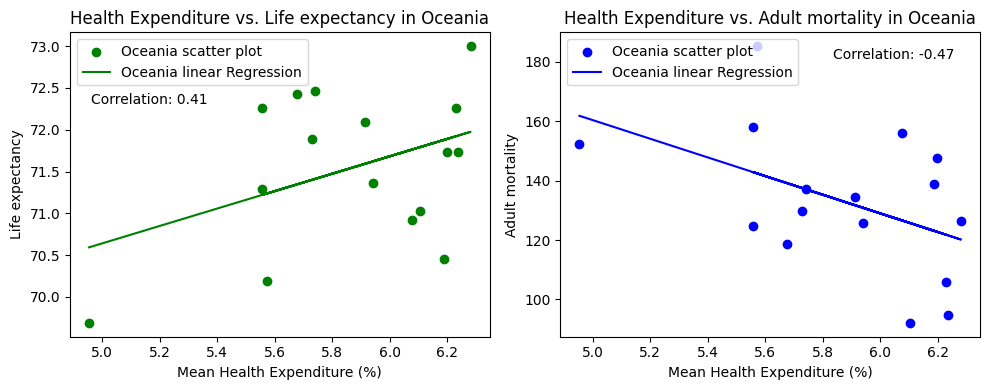

In [40]:
for continent_name in continents:
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    continent = globals()[continent_name]


    slope_life_gdp, intercept_life_gdp = np.polyfit(continent['mean_health_expenditure (%GDP)'].values,
                                                    continent['mean_life_expectancy'].values, 1)
    axs[0].scatter(continent['mean_health_expenditure (%GDP)'].values, continent['mean_life_expectancy'].values,
                   label=f"{continent_name} scatter plot", color="green")
    axs[0].plot(continent['mean_health_expenditure (%GDP)'].values,
                slope_life_gdp * continent['mean_health_expenditure (%GDP)'].values + intercept_life_gdp,
                color='green', label=f'{continent_name} linear Regression')
    axs[0].set_xlabel('Mean Health Expenditure (%)')
    axs[0].set_ylabel('Life expectancy')
    axs[0].set_title(f"Health Expenditure vs. Life expectancy in {continent_name}")
    axs[0].legend(loc="upper left")


    slope_mortality_gdp, intercept_mortality_gdp = np.polyfit(continent['mean_health_expenditure (%GDP)'].values,
                                                              continent['mean_adult_mortality'].values, 1)
    axs[1].scatter(continent['mean_health_expenditure (%GDP)'].values, continent['mean_adult_mortality'].values,
                   label=f"{continent_name} scatter plot", color="blue")
    axs[1].plot(continent['mean_health_expenditure (%GDP)'].values,
                slope_mortality_gdp * continent['mean_health_expenditure (%GDP)'].values + intercept_mortality_gdp,
                color='blue', label=f'{continent_name} linear Regression')
    axs[1].set_xlabel('Mean Health Expenditure (%)')
    axs[1].set_ylabel('Adult mortality')
    axs[1].set_title(f"Health Expenditure vs. Adult mortality in {continent_name}")
    axs[1].legend(loc="upper left")


    correlation_life_he = np.corrcoef(continent['mean_health_expenditure (%GDP)'].values,
                                       continent['mean_life_expectancy'].values)[0, 1]
    correlation_mortality_he = np.corrcoef(continent['mean_health_expenditure (%GDP)'].values,
                                            continent['mean_adult_mortality'].values)[0, 1]


    axs[0].text(0.05, 0.8, f'Correlation: {correlation_life_he:.2f}', transform=axs[0].transAxes, fontsize=10,
                ha='left', va='top')
    axs[1].text(0.65, 0.95, f'Correlation: {correlation_mortality_he:.2f}', transform=axs[1].transAxes, fontsize=10,
                ha='left', va='top')

    plt.tight_layout()
    plt.show()

In line with the patterns observed in the connections between the average GDP across continents and health metrics:
- There existed a positive association between health expenditure and life expectancy during the period spanning from 2000 to 2015.

- The data regarding adult mortality exhibited considerable dispersion around the regression line, with slightly negative to none correlation.



### **6.3 Global crisis (2008) effect on GDP and health indicators**

**1. The economic conditions may have become more predictable and consistent over time, with less fluctuation and variability in GDP measurements.**
- Evidences: the confidence intervals of the mean GDP values were generally larger in 2008 compared to 2015 (with caomparison to the GDP growth), with the exception of Asia.
- Possible reasons:
 - The global crisis brought about varied responses of different countries to the global crisis.
 - Consistent effort in promoting quity across nations.
 - China exceptional growth has created further disparity in Asia's GDP standard deviation.

**2. Regarding both life expectancy and adult mortality, no discernible trend is observed, regardless of the presence or absence of a global crisis.**
> This suggests that there may be limited visible impact of the global crisis on these health indicators. However, it is important to consider other factors that could influence life expectancy and adult mortality, such as healthcare access, quality of healthcare systems, socioeconomic conditions, and public health interventions. Further analysis incorporating these factors may provide deeper insights into the relationship between economic crises and health outcomes.

**3. It is reasonable to posit that while there may be a slight positive correlation between average GDP and health indicators, other factors warrant intensive consideration.**
> - The average GDP of each continent may not fully represent the actual GDP growth of individual countries within them. Due to the larger geographic boundaries of continents compared to countries, variations in economic trends may exist within each continent.
>  - For instance, the European economy may exhibit greater uniformity compared to Asia, potentially influenced by factors such as the presence of the European Union (EU).
> - Secondly, life expectancy and adult mortality represent long-term health metrics that undergo minimal change. Consequently, observable disruptions related to economic conditions may be limited.

## **7. Conclusion**

**1. There were some correlations between economic factors (GDP, health expenditure) and health indicators (life expectancy, adult mortality) from 2000 to 2015.**
- Average GDP is generally a better indicator for a continent's health than health expenditure (as % of GDP).
- The correlations of both economic factors was more prominent in life expectancy than in adult mortality.
 - Quality of healthcare and living standards directly impact life expectancy.
 - Various non-economic factors influence adult mortality, such as road safety and crime rates.


**2. Continents with higher mean GDP and health expenditure tended to exhibit higher life expectancy and lower adult mortality.**
- These associations could be attributed to generally greater resources for healthcare and higher living standards.

**3. Disruptive economic situations, such as the global crisis in 2008, did not have a visible impact on long-term health indicators.**


***
**Limitations and recommendations:**

**1. Limitations:** Using mean GDP and mean health expenditure to examine health condition of a continent might lead to
- Oversimplification: mean GDP and health expenditure overlook diversity within continents.
- Neglecting Inequality: mean values masks disparities in wealth and healthcare.
- Temporal Dynamics: mean values can miss temporal trends.
- External Factors: ignore external influences like politics and environment.

**2. Recommendations:** for a comprehensive understanding of the impact of GDP and health expenditure on healthcare, it is advisable to also examine short-term health indicators, such as healthcare utilization rates, disease prevalence trends, or vaccination coverage rates (especially during socio-economic disruptions).
***